# Deformation-mechanism maps and creep from one flow rule (W, Zr, Eurofer-97)

The rate-controlled model from `Unified_SRS_all_materials.ipynb` is evaluated here in **stress control**, as in creep tests and Frost–Ashby maps (`CreepModel` in `unified_plasticity.py`).

* **Dislocation rate:** for each $T$, $\tau(\dot\gamma)$ is tabulated from $10^{-14}$ to $10^{6}$ s$^{-1}$ and inverted. Where DSA makes $\tau(\dot\gamma)$ non-monotonic, the lowest-rate branch that reaches the stress is used.
* **Diffusional flow** (Nabarro–Herring + Coble) is an independent strain carrier, so its rate **adds**:
$$\dot\gamma_{\rm diff}=42\,\frac{\Omega\tau D_{\rm eff}}{k_BTd^2},\qquad D_{\rm eff}=D_v+\frac{\pi\delta}{d}D_b.$$
* **Creep** needs no separate law. It is the low-rate limit of the same flow rule: climb-controlled recovery of the forest ($\dot\rho=-K_{cl}D\rho^2$, which gives $n=3$), and precipitate bypass by local climb, which gives threshold-type creep in Eurofer.

**Fields** are labelled from the model's own diagnostics at each point, with no switches:

| field | criterion |
|---|---|
| kink-pair glide | $\tau^\star/\tau>0.5$ |
| obstacle-limited (athermal plateau) | $\tau^\star/\tau\le0.5$, $|\Lambda|\le1$ |
| dynamic strain aging (hatched band) | $\Lambda<-1$ ($m<0$). In stress control this branch is unstable (rate jumps, serrated flow), so it is drawn as the band of stresses it spans rather than as a field. |
| climb / recovery-controlled creep | $\Lambda>1$ |
| diffusional flow | $\dot\gamma_{\rm diff}>\dot\gamma_{\rm disl}$ |

> **Status of creep calibration.** Eurofer-97 is fitted jointly to Vanaja's tensile data and to 54 minimum creep rates (Fernández et al. 2005, digitized from their Fig. 1, plus one steady-state rate from Yu et al. 2005). Precipitate climb and forest recovery share one diffusivity. For W and Zr the creep fields are still **predictions** from tensile-only calibrations, and the W recovery constants are nominal placeholders. The upper temperature is cut at the $\alpha\to\beta$ transition for Zr (1136 K) and at $\alpha\to\gamma$ for Eurofer (~1100 K).

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.getcwd())
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import importlib, unified_plasticity as up, material_cards as mc
importlib.reload(up); importlib.reload(mc)
from unified_plasticity import *
from material_cards import *
plt.rcParams.update({"figure.dpi": 110, "axes.linewidth": 1.4, "font.size": 11})

FIELD_COL = ["#e8e8e8", "#cfe0f3", "#9ecae1", "#f4c9a8", "#c7e9c0"]
FIELD_LAB = ["kink-pair glide", "obstacle-limited plateau", "dynamic strain aging (m<0)",
             "climb / recovery creep", "diffusional flow"]
from matplotlib.patches import Patch as _P
cmap = ListedColormap(FIELD_COL); norm = BoundaryNorm(np.arange(-0.5, 5.5, 1), cmap.N)

SPEC = {  # T/Tm range (phase limits), tau/mu range
    "W":         dict(T=(0.05, 0.70), tm=(1e-6, 1e-2)),
    "Zr":        dict(T=(0.14, 1136/ZR_MAT.Tm), tm=(1e-6, 1e-2)),
    "Eurofer97": dict(T=(0.16, 1100/EU_Tm), tm=(1e-6, 1e-2)),
}
MAPS = {}
for name, d in MATERIALS.items():
    s = SPEC[name]; Tm = d["mat"].Tm
    T = np.linspace(s["T"][0], s["T"][1], 90) * Tm
    tm = np.logspace(np.log10(s["tm"][0]), np.log10(s["tm"][1]), 110)
    MAPS[name] = d["creep"](diffusion=True).mechanism_map(T, tm)
    print(name, "fields present:", sorted(set(np.unique(MAPS[name]["field"])) - {-1}))

W fields present: [np.int64(0), np.int64(1), np.int64(3), np.int64(4)]
Zr fields present: [np.int64(0), np.int64(1), np.int64(3), np.int64(4)]
Eurofer97 fields present: [np.int64(1), np.int64(3), np.int64(4)]


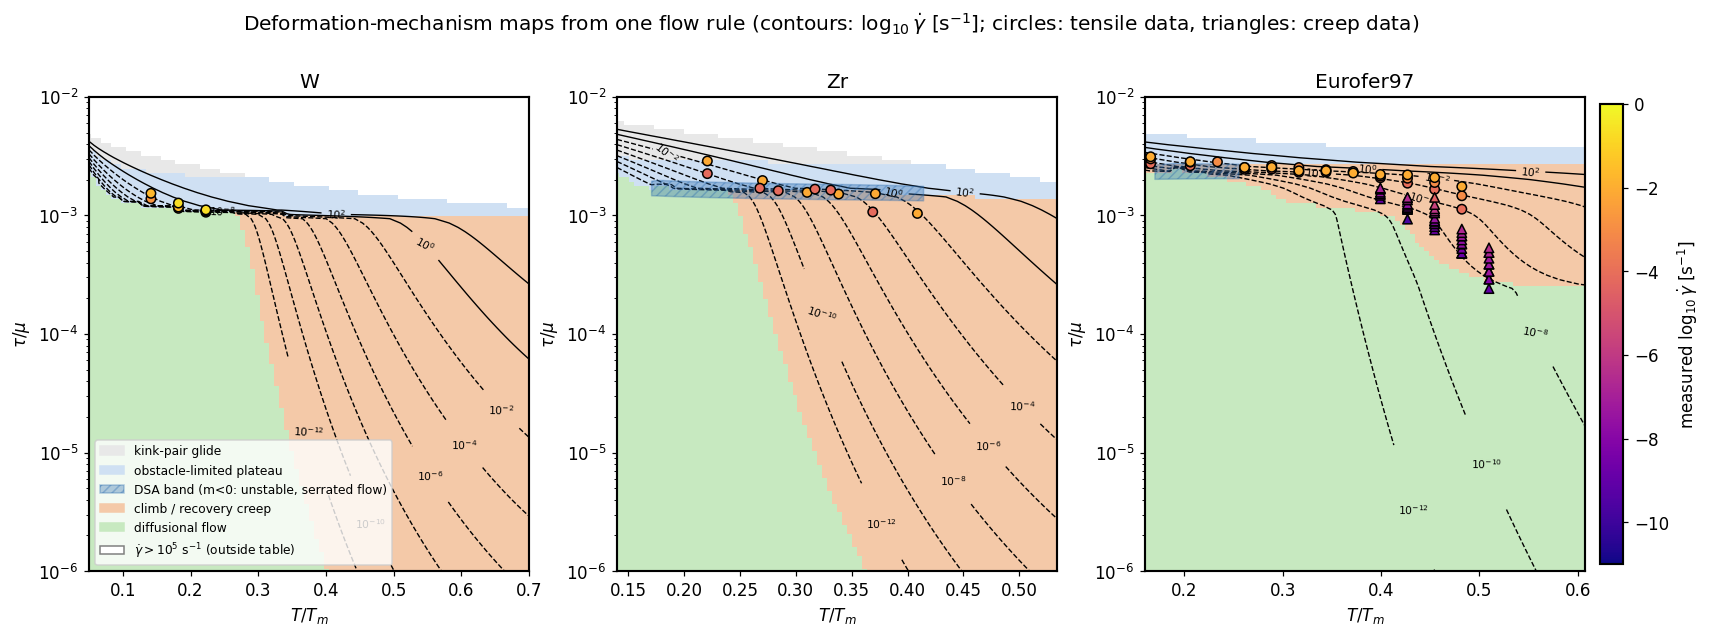

In [2]:
def draw_map(ax, name, show_data=True):
    mp = MAPS[name]; d = MATERIALS[name]; Tm = d["mat"].Tm
    X, Y = mp["T"] / Tm, mp["tau_over_mu"]
    F = np.ma.masked_less(mp["field"].T, 0)
    ax.pcolormesh(X, Y, F, cmap=cmap, norm=norm, shading="auto")
    lo, hi = mp["dsa_band"]
    ok = np.isfinite(lo)
    ax.fill_between(X, lo / 1.15, hi * 1.15, where=ok, facecolor="#2b6cb0", alpha=0.35, edgecolor="#2b6cb0",
                    hatch="////", linewidth=1.0, zorder=3)
    lg = np.log10(np.clip(mp["rate"].T, 1e-300, None))
    levels = np.arange(-12, 3, 2)
    cs = ax.contour(X, Y, lg, levels=levels, colors="k", linewidths=0.9)
    ax.clabel(cs, fmt=lambda v: fr"$10^{{{int(v)}}}$", fontsize=7)
    if show_data:
        pts = [p for p in tensile_points() if p[0] == name]
        T = np.array([p[1] for p in pts]); e = np.array([p[2] for p in pts]); t = np.array([p[3] for p in pts]) * 1e6
        sc = ax.scatter(T / Tm, t / d["mat"].mu(T), c=np.log10(e / d["M"]), cmap="plasma", vmin=-11, vmax=0,
                        edgecolors="k", s=38, zorder=5)
        if name == "Eurofer97":
            Cc = np.vstack([EU_CREEP, EU_CREEP_YU])
            ax.scatter(Cc[:, 0] / Tm, Cc[:, 1] * 1e6 * d["M"] / d["mat"].mu(Cc[:, 0]), c=np.log10(Cc[:, 2] / d["M"]),
                       cmap="plasma", vmin=-11, vmax=0, marker="^", edgecolors="k", s=38, zorder=5)
    ax.set(xscale="linear", yscale="log", xlabel=r"$T/T_m$", ylabel=r"$\tau/\mu$", title=name,
           xlim=(X[0], X[-1]), ylim=(Y[0], Y[-1]))
    return sc if show_data else None

fig, axs = plt.subplots(1, 3, figsize=(18, 5.6))
for ax, name in zip(axs, MATERIALS):
    sc = draw_map(ax, name)
cb = fig.colorbar(sc, ax=axs, fraction=0.015, pad=0.01); cb.set_label(r"measured $\log_{10}\dot\gamma$ [s$^{-1}$]")
hand = [Patch(color=c, label=l) for i, (c, l) in enumerate(zip(FIELD_COL, FIELD_LAB)) if i != 2]
hand.insert(2, Patch(facecolor="#2b6cb0", alpha=0.35, edgecolor="#2b6cb0", hatch="////", label="DSA band (m<0: unstable, serrated flow)"))
hand.append(Patch(facecolor="white", edgecolor="0.5", label=r"$\dot\gamma>10^{5}$ s$^{-1}$ (outside table)"))
axs[0].legend(handles=hand, fontsize=8, loc="lower left")
fig.suptitle(r"Deformation-mechanism maps from one flow rule (contours: $\log_{10}\dot\gamma$ [s$^{-1}$]; circles: tensile data, triangles: creep data)", y=1.02)
plt.show()

## Stress parity: every tensile/SRS point from all three materials
Each point is the model stress at the measured $T$ and rate, plotted against the measured stress (shear). W micropillar CRSS values are plotted at the middle rate of that study ($5\times10^{-3}$ s$^{-1}$).

overall MAPE = 3.6%,  within 10%: 94% of points


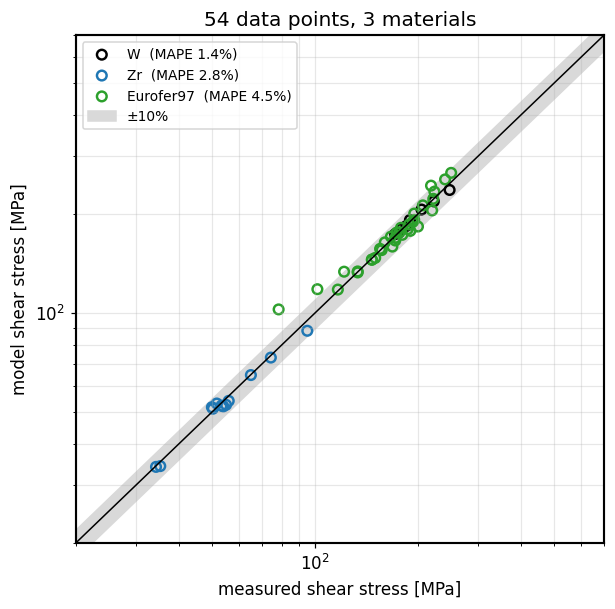

In [3]:
pts = tensile_points()
fig, ax = plt.subplots(figsize=(6.2, 6))
cols = {"W": "k", "Zr": "tab:blue", "Eurofer97": "tab:green"}
allm, alld = [], []
for name in MATERIALS:
    P = [p for p in pts if p[0] == name]
    T = np.array([p[1] for p in P]); e = np.array([p[2] for p in P]); t = np.array([p[3] for p in P])
    tm = MATERIALS[name]["make"]().solve(e / MATERIALS[name]["M"], T, details=False)["tau"] / 1e6
    ax.scatter(t, tm, s=40, facecolors="none", edgecolors=cols[name], linewidths=1.6,
               label=f"{name}  (MAPE {np.mean(np.abs(tm-t)/t)*100:.1f}%)")
    allm += list(tm); alld += list(t)
lim = [20, 700]
ax.plot(lim, lim, "k-", lw=1); ax.fill_between(lim, [l*0.9 for l in lim], [l*1.1 for l in lim], color="0.85", zorder=0, label="±10%")
ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim, xlabel="measured shear stress [MPa]",
       ylabel="model shear stress [MPa]", title=f"{len(alld)} data points, 3 materials")
ax.legend(fontsize=9); ax.grid(alpha=0.3, which="both"); plt.show()
alld, allm = np.array(alld), np.array(allm)
print(f"overall MAPE = {np.mean(np.abs(allm-alld)/alld)*100:.1f}%,  within 10%: {np.mean(np.abs(allm-alld)/alld<0.1)*100:.0f}% of points")

## All materials on one normalized map
The same iso-rate contours are drawn for each material in homologous coordinates. With the same kinetic structure, the materials differ in *where* the kink-pair, plateau, DSA and creep regimes sit.

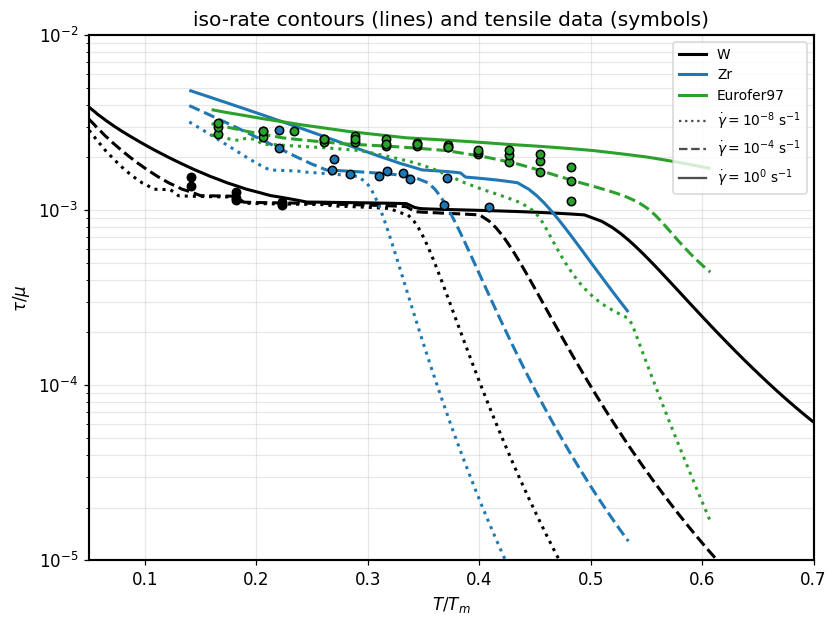

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 6.2))
ls = {-8: ":", -4: "--", 0: "-"}
for name in MATERIALS:
    mp = MAPS[name]; Tm = MATERIALS[name]["mat"].Tm
    lg = np.log10(np.clip(mp["rate"].T, 1e-300, None))
    for lev, st in ls.items():
        ax.contour(mp["T"]/Tm, mp["tau_over_mu"], lg, levels=[lev], colors=cols[name], linestyles=st, linewidths=2)
    P = [p for p in pts if p[0] == name]
    T = np.array([p[1] for p in P]); t = np.array([p[3] for p in P]) * 1e6
    ax.scatter(T/Tm, t/MATERIALS[name]["mat"].mu(T), s=30, color=cols[name], edgecolors="k", zorder=5)
h = [plt.Line2D([], [], color=c, lw=2, label=n) for n, c in cols.items()]
h += [plt.Line2D([], [], color="0.3", ls=s, label=fr"$\dot\gamma=10^{{{k}}}$ s$^{{-1}}$") for k, s in ls.items()]
ax.legend(handles=h, fontsize=9)
ax.set(yscale="log", xlabel=r"$T/T_m$", ylabel=r"$\tau/\mu$", ylim=(1e-5, 1e-2), xlim=(0.05, 0.7),
       title="iso-rate contours (lines) and tensile data (symbols)")
ax.grid(alpha=0.3, which="both"); plt.show()

## Creep: Eurofer-97 against data, and predictions for W and Zr
Minimum (steady-state) creep rate against applied stress, with $\dot\epsilon=M_s\dot\gamma$ and $\sigma=\tau/M_s$. Eurofer symbols are the digitized minimum creep rates of Fernández et al. (2005); the star is the 550 °C / 300 MPa steady-state rate of Yu et al. (2005).

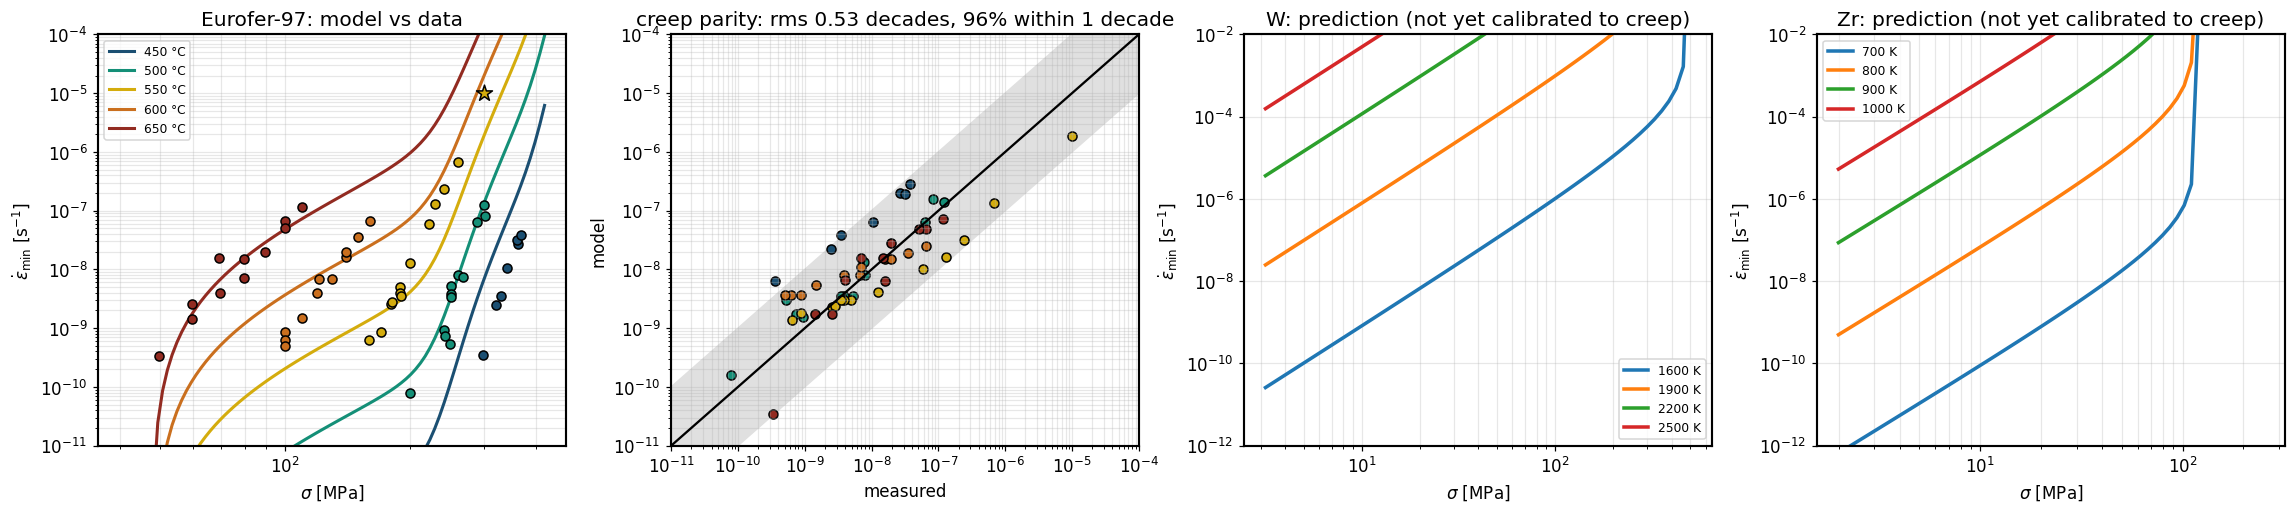

In [5]:
fig, axs = plt.subplots(1, 4, figsize=(21, 4.8))
tc = {723: "#1b4f72", 773: "#148f77", 823: "#d4ac0d", 873: "#ca6f1e", 923: "#922b21"}
cmE = creep_Eurofer(); sg = np.logspace(np.log10(40), np.log10(420), 90)
ax = axs[0]
for T, c in tc.items():
    ax.loglog(sg, cmE.rate(sg[None, :]*1e6*EU_M, np.array([float(T)]))["total"][0]*EU_M, color=c, lw=2, label=f"{T-273} °C")
    k = EU_CREEP[:, 0] == T
    ax.scatter(EU_CREEP[k, 1], EU_CREEP[k, 2], color=c, edgecolors="k", s=35, zorder=5)
ax.scatter(EU_CREEP_YU[:, 1], EU_CREEP_YU[:, 2], marker="*", s=120, color=tc[823], edgecolors="k", zorder=6)
ax.set(xlabel=r"$\sigma$ [MPa]", ylabel=r"$\dot\epsilon_{\min}$ [s$^{-1}$]", ylim=(1e-11, 1e-4), title="Eurofer-97: model vs data")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")

Cc = np.vstack([EU_CREEP, EU_CREEP_YU]); pred = np.empty(len(Cc))
for T in np.unique(Cc[:, 0]):
    k = Cc[:, 0] == T
    pred[k] = cmE.rate(Cc[k, 1][None, :]*1e6*EU_M, np.array([T]))["total"][0]*EU_M
ax = axs[1]
for T, c in tc.items():
    k = Cc[:, 0] == T; ax.scatter(Cc[k, 2], pred[k], color=c, edgecolors="k", s=35)
ax.plot([1e-11, 1e-4], [1e-11, 1e-4], "k-"); ax.fill_between([1e-11, 1e-4], [1e-12, 1e-5], [1e-10, 1e-3], color="0.88", zorder=0)
le = np.log10(pred) - np.log10(Cc[:, 2])
ax.set(xscale="log", yscale="log", xlim=(1e-11, 1e-4), ylim=(1e-11, 1e-4), xlabel="measured", ylabel="model",
       title=f"creep parity: rms {np.sqrt(np.mean(le**2)):.2f} decades, {np.mean(np.abs(le)<1)*100:.0f}% within 1 decade")
ax.grid(alpha=0.3, which="both")

setups = {"W": (np.array([1600., 1900., 2200., 2500.]), np.logspace(0.5, 2.7, 60)),
          "Zr": (np.array([700., 800., 900., 1000.]), np.logspace(0.3, 2.4, 60))}
for ax, (name, (T, sig)) in zip(axs[2:], setups.items()):
    d = MATERIALS[name]; M = d["M"]
    r = d["creep"]().rate(np.tile(sig * 1e6 * M, (len(T), 1)), T)
    for i, Ti in enumerate(T):
        ax.loglog(sig, r["total"][i] * M, lw=2.3, label=f"{Ti:.0f} K")
    ax.set(xlabel=r"$\sigma$ [MPa]", ylabel=r"$\dot\epsilon_{\min}$ [s$^{-1}$]", ylim=(1e-12, 1e-2),
           title=f"{name}: prediction (not yet calibrated to creep)")
    ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Next step: creep data for W and Zr
Add minimum-creep-rate tables ($T$, $\sigma$, $\dot\epsilon_{\min}$) for W and Zr to `material_cards.py`, in the same form as `EU_CREEP`. The recovery constants ($K_{cl}$, $Q_D$) can then be fitted jointly with the tensile data, as was done for Eurofer-97.